# Final Project - Text Mining for AI

This notebook contains experiments and results for:
- sentiment analysis
- topic analysis
- named entity recognition/classification

# Imports

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import os
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ModuleNotFoundError: No module named 'sklearn'

# ======================================
# SENTIMENT ANALYSIS
# ======================================

Dataset Loading and Preprocessing

In [5]:
data = []

dataset_path = "airlinetweets"

for label in ["positive", "negative", "neutral"]:
    folder_path = os.path.join(dataset_path, label)

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        with open(file_path, "r", encoding="utf-8") as file:
            text = file.read()

            data.append({
                "text": text,
                "label": label
            })

df = pd.DataFrame(data)

In [6]:
df.head()

,text,label
0,"""@AmericanAir just curious. Thanks for the res...",positive
1,@united thanks for all the help! Totally appre...,positive
2,@JetBlue thanks. Line moved quick. Already done.,positive
3,@AmericanAir Aww cool! It's nice to know they ...,positive
4,@SouthwestAir Great job with the Passbook inte...,positive


In [7]:
print(df["label"].value_counts())

label
negative    1750
neutral     1515
positive    1490
Name: count, dtype: int64


SVM + TF-IDF Sentiment Analysis

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

In [9]:
# Create and train the model
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [10]:
# Predictions
predictions = model.predict(X_test)

In [11]:
# Evaluation (classification report)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    negative       0.84      0.90      0.87       328
     neutral       0.78      0.80      0.79       296
    positive       0.90      0.80      0.85       327

    accuracy                           0.84       951
   macro avg       0.84      0.84      0.84       951
weighted avg       0.84      0.84      0.84       951



The TF-IDF + SVM model achieved an accuracy of 84%. The model performs best on negative and positive sentiment, while neutral sentiment is slightly more difficult to classify.

In [12]:
for i in range(5):
    print("TEXT:", X_test.iloc[i])
    print("PREDICTED:", predictions[i])
    print("ACTUAL:", y_test.iloc[i])
    print("-" * 50)

TEXT: @SouthwestAir @SouthwestOliver that's a great FA right there.
PREDICTED: positive
ACTUAL: positive
--------------------------------------------------
TEXT: "@united flight landed 13 hours ago
PREDICTED: negative
ACTUAL: negative
--------------------------------------------------
TEXT: "@united at its worse. Can't figure how to pack plane
PREDICTED: negative
ACTUAL: negative
--------------------------------------------------
TEXT: @AmericanAir Am I upgraded on my next flight?
PREDICTED: neutral
ACTUAL: neutral
--------------------------------------------------
TEXT: @united that's cool - now what?
PREDICTED: negative
ACTUAL: negative
--------------------------------------------------


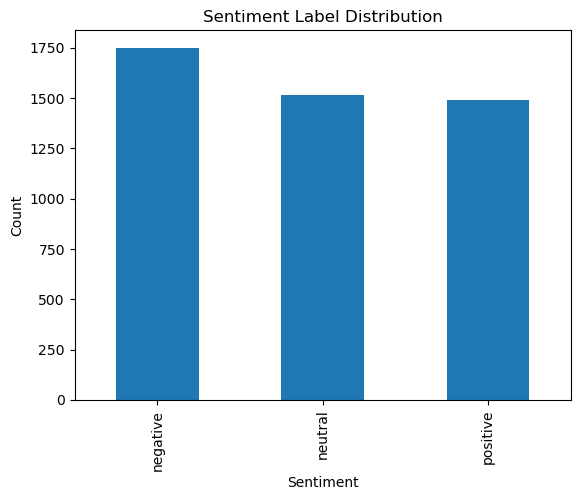

In [13]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()


ROBERTA Sentiment Analysis


In [ ]:
# RoBERTa Sentiment Analysis using HuggingFace Transformers
from transformers import pipeline

# Load pre-trained RoBERTa-based sentiment model
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Predict on test set
roberta_predictions = []
roberta_scores = []

for text in X_test:
    result = sentiment_model(text)
    label = result[0]['label']
    score = result[0]['score']
    
    # Convert to 3-class: use confidence threshold for neutral
    if score < 0.65:
        pred_label = 'neutral'
    elif label == 'POSITIVE':
        pred_label = 'positive'
    else:  # NEGATIVE
        pred_label = 'negative'
    
    roberta_predictions.append(pred_label)
    roberta_scores.append(score)

roberta_predictions = pd.Series(roberta_predictions)
roberta_report = classification_report(y_test, roberta_predictions, output_dict=True)

print(classification_report(y_test, roberta_predictions))

Result Comparison and Error Analysis

In [ ]:
# ======================================
# RESULT COMPARISON
# ======================================

svm_report = classification_report(y_test, predictions, output_dict=True)

comparison_results = pd.DataFrame([
    {
        "model": "TF-IDF + SVM",
        "accuracy": svm_report["accuracy"],
        "negative_f1": svm_report["negative"]["f1-score"],
        "neutral_f1": svm_report["neutral"]["f1-score"],
        "positive_f1": svm_report["positive"]["f1-score"]
    },
    {
        "model": "RoBERTa (DistilBERT)",
        "accuracy": roberta_report["accuracy"],
        "negative_f1": roberta_report["negative"]["f1-score"],
        "neutral_f1": roberta_report["neutral"]["f1-score"],
        "positive_f1": roberta_report["positive"]["f1-score"]
    }
])

comparison_results

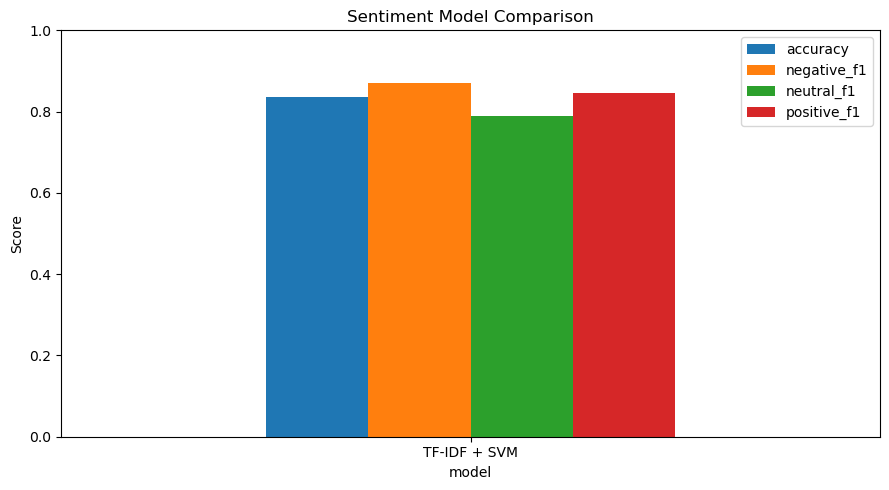

In [15]:
comparison_results.set_index("model").plot(kind="bar", figsize=(9, 5))

plt.title("Sentiment Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# End of notebook

In [ ]:
# Load test set
test_df = pd.read_csv("sentiment-topic-test.tsv", sep="\t")
X_test_sent = test_df["sentence"].values
y_test_sent = test_df["sentiment"].values

print(f"Test set size: {len(X_test_sent)} sentences")
print(f"Class distribution:\n{pd.Series(y_test_sent).value_counts()}")

# SVM predictions on test set
svm_test_predictions = model.predict(X_test_sent)

# RoBERTa predictions on test set
roberta_test_predictions = []
for text in X_test_sent:
    result = sentiment_model(text)
    label = result[0]['label']
    score = result[0]['score']
    
    if score < 0.65:
        pred_label = 'neutral'
    elif label == 'POSITIVE':
        pred_label = 'positive'
    else:
        pred_label = 'negative'
    
    roberta_test_predictions.append(pred_label)

roberta_test_predictions = pd.Series(roberta_test_predictions).values

# Classification reports
print("\n=== SVM Results on Test Set ===")
svm_test_report = classification_report(y_test_sent, svm_test_predictions, output_dict=True)
print(classification_report(y_test_sent, svm_test_predictions))

print("\n=== RoBERTa Results on Test Set ===")
roberta_test_report = classification_report(y_test_sent, roberta_test_predictions, output_dict=True)
print(classification_report(y_test_sent, roberta_test_predictions))

In [ ]:
# Compare test set performance
test_comparison = pd.DataFrame([
    {
        "model": "TF-IDF + SVM",
        "accuracy": svm_test_report["accuracy"],
        "negative_f1": svm_test_report["negative"]["f1-score"],
        "neutral_f1": svm_test_report["neutral"]["f1-score"],
        "positive_f1": svm_test_report["positive"]["f1-score"]
    },
    {
        "model": "RoBERTa (DistilBERT)",
        "accuracy": roberta_test_report["accuracy"],
        "negative_f1": roberta_test_report["negative"]["f1-score"],
        "neutral_f1": roberta_test_report["neutral"]["f1-score"],
        "positive_f1": roberta_test_report["positive"]["f1-score"]
    }
])

print("Test Set Performance Comparison:")
print(test_comparison)

# Visualize comparison
test_comparison.set_index("model").plot(kind="bar", figsize=(9, 5))
plt.title("Test Set Performance: SVM vs RoBERTa")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Show correct predictions (both models agree with ground truth)
print("=== TRUE POSITIVES (Both models correct) ===\n")
correct_both = (svm_test_predictions == y_test_sent) & (roberta_test_predictions == y_test_sent)
for i, (sent, true_label) in enumerate(zip(X_test_sent[correct_both][:3], y_test_sent[correct_both][:3])):
    print(f"Sentence: {sent}")
    print(f"Ground Truth: {true_label}")
    print(f"SVM Pred: {svm_test_predictions[correct_both][i]}, RoBERTa Pred: {roberta_test_predictions[correct_both][i]}")
    print()

# Show SVM errors
print("\n=== SVM ERRORS ===\n")
svm_errors = svm_test_predictions != y_test_sent
for i, (sent, true_label, pred_label) in enumerate(zip(X_test_sent[svm_errors][:2], y_test_sent[svm_errors][:2], svm_test_predictions[svm_errors][:2])):
    print(f"Sentence: {sent}")
    print(f"Ground Truth: {true_label}, Predicted: {pred_label}")
    print()

# Show RoBERTa errors
print("\n=== RoBERTa ERRORS ===\n")
roberta_errors = roberta_test_predictions != y_test_sent
for i, (sent, true_label, pred_label) in enumerate(zip(X_test_sent[roberta_errors][:2], y_test_sent[roberta_errors][:2], roberta_test_predictions[roberta_errors][:2])):
    print(f"Sentence: {sent}")
    print(f"Ground Truth: {true_label}, Predicted: {pred_label}")
    print()